# PJME Hourly Load Forecasting: Hybrid Prophet-XGBoost Model

This notebook demonstrates a hybrid modeling approach for PJME hourly load forecasting. We combine time series feature engineering and Prophet-based preprocessing with an XGBoost regression model to improve forecast accuracy.

## Workflow Overview

1. **Data Loading & Feature Engineering**
    - Load and preprocess PJME hourly load data.
    - Create time-based features (hour, day of week, quarter, etc.).
    - Identify and handle outliers and hurricane events.

2. **Train/Test Split**
    - Split the data into training and test sets based on a cutoff date.

3. **Prophet Preprocessing**
    - Use Prophet to model trend, seasonality, and holiday effects.
    - Extract Prophet's predictions and residuals as additional features.

4. **Hybrid Model: XGBoost**
    - Train an XGBoost regressor using engineered features and Prophet outputs.
    - Evaluate performance on the test set.

## Key Variables

- `df`: Original dataframe with time-based features.
- `train_set`, `test_set`: Split datasets for model training and evaluation.
- `cleaned_train_set`: Outlier-cleaned training data.
- `hurricane_dates`: DataFrame of hurricane event windows.
- `best_params`: Dictionary of optimal parameters for preprocessing.
- `output_dir`: Directory for saving intermediate and final results.

---

**Notes:**  
1. adding monthly to prophet model (horizon= 2y) gave negligible difference.

2. It seems that forecasting a horizon of 3 years is definately bad.
    - model is unlikely to capture newer trends, and may be stuck to older ones.
    - Seasonal/Trend Shifts Over Long Horizons

**Next Steps:**  
- train-test-split: train(2002-2016) / test(2017-2018)
- maybe reevaluate MAPE: 
    - with shorter horizons.
    - maybe compare 1/2/3/4/5 months.
    - use cross-validation for the entire year


- Implement the XGBoost hybrid model using the engineered features and Prophet outputs.



In [95]:
# import libraries and modules
import os
import json
import optuna
import plotly
import pickle
import joblib
import kaleido
import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet
from xgboost import plot_importance
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from utils.data_utils import *
from utils.model_utils import *

import warnings
warnings.filterwarnings('ignore')

In [76]:
# load df 

output_dir = 'output_hybrid_v3'

df = load_data('data/PJME_hourly.csv')

# train_set, test_set = split_train_test(df, '2017-01-01') #cut-off date 

In [77]:
# make sure ds is in ascending order
df = df.sort_values(by='ds').reset_index(drop=True)

check_missing_hours(df)

Missing timestamps: 30/145392
2002-04-07 03:00:00
2002-10-27 02:00:00
2003-04-06 03:00:00
2003-10-26 02:00:00
2004-04-04 03:00:00
2004-10-31 02:00:00
2005-04-03 03:00:00
2005-10-30 02:00:00
2006-04-02 03:00:00
2006-10-29 02:00:00
2007-03-11 03:00:00
2007-11-04 02:00:00
2008-03-09 03:00:00
2008-11-02 02:00:00
2009-03-08 03:00:00
2009-11-01 02:00:00
2010-03-14 03:00:00
2010-11-07 02:00:00
2010-12-10 00:00:00
2011-03-13 03:00:00
2011-11-06 02:00:00
2012-03-11 03:00:00
2012-11-04 02:00:00
2013-03-10 03:00:00
2013-11-03 02:00:00
2014-03-09 03:00:00
2015-03-08 03:00:00
2016-03-13 03:00:00
2017-03-12 03:00:00
2018-03-11 03:00:00


### Analysis of Missing Timestamps

The list of missing timestamps in the dataset (e.g., `2002-04-07 03:00:00`, `2002-10-27 02:00:00`, etc.) strongly suggests that these gaps are due to Daylight Saving Time (DST) transitions. Typically, during the "spring forward" transition, clocks skip from 2:00 AM to 3:00 AM, resulting in the absence of the 2:00–3:00 AM hour. Conversely, during the "fall back" transition, the 2:00 AM hour is repeated, which can sometimes cause duplicate or ambiguous timestamps.

The pattern and timing of the missing hours align with the expected DST changes in the United States, indicating that the dataset is missing hours due to these time adjustments rather than random data loss.

**Note**
- For 'lagging' and other features to be used in XGBoost

In [78]:
df

,ds,y
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0
...,...,...
145361,2018-08-02 20:00:00,44057.0
145362,2018-08-02 21:00:00,43256.0
145363,2018-08-02 22:00:00,41552.0
145364,2018-08-02 23:00:00,38500.0


In [79]:
# Set 'ds' as index for time-based operations
df = df.set_index('ds')

# Print the number of duplicate timestamps
print("Number of duplicates:", df.index.duplicated().sum())

# Print all rows that are duplicates (excluding the first occurrence)
print("Duplicate rows:")
print(df[df.index.duplicated(keep=False)])

Number of duplicates: 4
Duplicate rows:
                           y
ds                          
2014-11-02 02:00:00  23755.0
2014-11-02 02:00:00  22935.0
2015-11-01 02:00:00  21567.0
2015-11-01 02:00:00  21171.0
2016-11-06 02:00:00  20795.0
2016-11-06 02:00:00  21692.0
2017-11-05 02:00:00  21236.0
2017-11-05 02:00:00  20666.0


## Handling Duplicate Timestamps and DST-Related Gaps

During Daylight Saving Time transitions, two issues occur:

1. **“Fall-back” duplicates**  
   In autumn, clocks move back one hour. For example, on `2014-11-02`, two different load readings share the timestamp `02:00:00`. Leaving both rows creates ambiguity for lagged features, since “one hour ago” could refer to either reading.

2. **“Spring-forward” gaps**  
   In spring, clocks skip ahead one hour. For example, `2002-04-07 03:00:00` is missing. Any operation that assumes a continuous hourly index (e.g. `.shift(1)` or `.rolling(24)`) fails at these gaps.

---

### Resolving Duplicate Timestamps

- **Cause:** Two readings for the same nominal hour occur when the clock is set back.  
- **Solution:** Aggregate duplicates by taking their mean. This preserves information from both readings rather than dropping one arbitrarily.


In [80]:
# simple linear (time) interpolation 

# Identify and aggregate duplicates by taking the mean of 'y'
df = df.groupby(level=0).mean()

# Create complete hourly index
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')

# Reindex to include all timestamps
df = df.reindex(full_range)

# Interpolate and fill
df['y'] = df['y'].interpolate(method='time')
df['y'] = df['y'].ffill().bfill()

df = df.reset_index().rename(columns={'index': 'ds'})
df['ds'] = pd.to_datetime(df['ds'])  # Ensure it's datetime
check_missing_hours(df)

Missing timestamps: 0/145392


In [ ]:
def create_features_xgboost(df, lags=[1, 24], rolling_windows=[24]):
    """
    Create temporal, cyclical, lag, and rolling features from the datetime column.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datetime) and 'y' (target) columns.
        lags (list): List of lag periods to create lag features.
        rolling_windows (list): List of window sizes for rolling statistics shifted by 1, up to yₜ₋₁ instead of yₜ.

    Returns:
        pd.DataFrame: DataFrame with added features.

    Note:
        Introducing information up to yₜ₋₁ such as from lag and rolling essentially makes it a 
        hour-ahead forecast instead of a more 'honest' forecast.
    """
    # Temporal features
    df['hour'] = df['ds'].dt.hour
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Quarterly (annual) features
    quarters = {
        1: 'Q1_Jan-Mar',
        2: 'Q2_Apr-Jun',
        3: 'Q3_Jul-Sep',
        4: 'Q4_Oct-Dec'
    }
    df['quarter'] = df['ds'].dt.quarter.map(quarters)

    # Cyclical hour encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Lag features
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # Rolling statistics
    # Shift back by 1 to avoid leaking future data
    for window in rolling_windows:
        shift = df['y'].shift(1).rolling(window=window)
        df[f'rolling_mean_{window}'] = shift.mean()
        df[f'rolling_std_{window}'] = shift.std()

    # Drop rows with NaN values caused by shifting/rolling
    df = df.dropna().reset_index(drop=True)

    return df

In [ ]:
def create_features_xgboost_honest(df, lags=[1, 24], rolling_windows=[24]):
    """
    Create temporal, cyclical, lag, and rolling features from the datetime column.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datetime) and 'y' (target) columns.
        lags (list): List of lag periods to create lag features.
        rolling_windows (list): List of window sizes for rolling statistics shifted by 1, up to yₜ₋₁ instead of yₜ.

    Returns:
        pd.DataFrame: DataFrame with added features.

    Note:
        Introducing information up to yₜ₋₁ such as from lag and rolling essentially makes it a 
        hour-ahead forecast instead of a more 'honest' forecast.
    """
    # Temporal features
    df['hour'] = df['ds'].dt.hour
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Quarterly (annual) features
    quarters = {
        1: 'Q1_Jan-Mar',
        2: 'Q2_Apr-Jun',
        3: 'Q3_Jul-Sep',
        4: 'Q4_Oct-Dec'
    }
    df['quarter'] = df['ds'].dt.quarter.map(quarters)

    # Cyclical hour encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Lag features
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # Rolling statistics
    # Shift back by 1 to avoid leaking future data
    for window in rolling_windows:
        shift = df['y'].shift(1).rolling(window=window)
        df[f'rolling_mean_{window}'] = shift.mean()
        df[f'rolling_std_{window}'] = shift.std()

    # Drop rows with NaN values caused by shifting/rolling
    df = df.dropna().reset_index(drop=True)

    return df

In [84]:
# Basic Feature engineering
df = create_features_xgboost(df, lags=[1, 24], rolling_windows=[24])

#One hot encode
df = pd.get_dummies(df, columns=['quarter'])

df.head()

,ds,y,hour,day_of_week,is_weekend,hour_sin,hour_cos,lag_1,lag_24,rolling_mean_24,rolling_std_24,quarter_Q1_Jan-Mar,quarter_Q2_Apr-Jun,quarter_Q3_Jul-Sep,quarter_Q4_Oct-Dec
0,2002-01-02 01:00:00,28121.0,1,2,0,0.258819,0.965926,29563.0,30393.0,31017.500000,2423.666231,True,False,False,False
1,2002-01-02 02:00:00,27437.0,2,2,0,0.500000,0.866025,28121.0,29265.0,30922.833333,2492.512817,True,False,False,False
2,2002-01-02 03:00:00,27301.0,3,2,0,0.707107,0.707107,27437.0,28357.0,30846.666667,2572.037370,True,False,False,False
3,2002-01-02 04:00:00,27533.0,4,2,0,0.866025,0.500000,27301.0,27899.0,30802.666667,2624.967920,True,False,False,False
4,2002-01-02 05:00:00,28405.0,5,2,0,0.965926,0.258819,27533.0,28057.0,30787.416667,2643.567746,True,False,False,False


In [86]:
from pandas.tseries.offsets import MonthEnd

def split_test_set_by_month(test_set):
    """
    Splits the test_set DataFrame into a list of DataFrames, each containing one month of data.
    Returns: List of DataFrames, one per month in test_set.
    """
    
    months = test_set['ds'].dt.to_period('M').unique()
    print(f"Total splits: {len(months)}")

    monthly_splits = []
    for month in months:
        mask = test_set['ds'].dt.to_period('M') == month
        monthly_splits.append(test_set[mask])

        first = test_set[mask]['ds'].min()
        last = test_set[mask]['ds'].max()

        print(f"Month: {month}")
        print(f"{first} to {last} \n")

    return monthly_splits

def rolling_test_horizons(test_set, max_months=12):
    """
    For each horizon from 1 to max_months, returns a list of DataFrames,
    where each DataFrame contains the first N months of the test set.
    """
    start = test_set['ds'].min()
    horizons = []
    for n in range(1, max_months + 1):
        end = (start + MonthEnd(n))
        mask = (test_set['ds'] >= start) & (test_set['ds'] <= end)
        horizons.append(test_set[mask])
    return horizons

In [87]:
train_set, test_set = split_train_test(df,'2017-08-01')

print(f"train_set: {train_set['ds'].min()} to {train_set['ds'].max()}")
print(f"test_set : {test_set['ds'].min()} to {test_set['ds'].max()}")

train_set: 2002-01-02 01:00:00 to 2017-07-31 23:00:00
test_set : 2017-08-01 00:00:00 to 2018-08-03 00:00:00


In [88]:
monthly_splits = split_test_set_by_month(test_set)

# Drop last partial month if it's shorter than a full month (e.g., < 28 days)
full_month_splits = [df for df in monthly_splits if len(df) >= 28 * 24]

# full_month_splits[-1]['ds'].min()

Total splits: 13
Month: 2017-08
2017-08-01 00:00:00 to 2017-08-31 23:00:00 

Month: 2017-09
2017-09-01 00:00:00 to 2017-09-30 23:00:00 

Month: 2017-10
2017-10-01 00:00:00 to 2017-10-31 23:00:00 

Month: 2017-11
2017-11-01 00:00:00 to 2017-11-30 23:00:00 

Month: 2017-12
2017-12-01 00:00:00 to 2017-12-31 23:00:00 

Month: 2018-01
2018-01-01 00:00:00 to 2018-01-31 23:00:00 

Month: 2018-02
2018-02-01 00:00:00 to 2018-02-28 23:00:00 

Month: 2018-03
2018-03-01 00:00:00 to 2018-03-31 23:00:00 

Month: 2018-04
2018-04-01 00:00:00 to 2018-04-30 23:00:00 

Month: 2018-05
2018-05-01 00:00:00 to 2018-05-31 23:00:00 

Month: 2018-06
2018-06-01 00:00:00 to 2018-06-30 23:00:00 

Month: 2018-07
2018-07-01 00:00:00 to 2018-07-31 23:00:00 

Month: 2018-08
2018-08-01 00:00:00 to 2018-08-03 00:00:00 



In [ ]:
#Optuna study
results = {}

def objective(trial):
    """
    Objective function to optimize Prophet model hyperparameters along with the cleaning parameters.

    Uses cross-validation with specified settings and returns the mean MAPE.
    """
    # Clean the training data using hyperparameter suggestions from the trial
    cleaned_train_set, hurricane_dates = clean_train_data(trial, train_set)
    
    # Prophet hyperparameter suggestions from the trial
    prophet_params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.05, log=True),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.3, 0.9),
        'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 5.0, log=True),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.5, 12),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['multiplicative', 'additive']),
        'yearly_seasonality': trial.suggest_int('yearly_seasonality', 4, 12)
    }
    
    # Initialize the Prophet model using the provided parameters and hurricane dates
    model = Prophet(
        **prophet_params,
        holidays=hurricane_dates,
        daily_seasonality=False,
        weekly_seasonality=False
        )
    model.add_country_holidays('US')
    
    # Fit the model on the cleaned training data.
    try:
        model.fit(cleaned_train_set)
    except Exception as e:
        print(f"Fitting failed: {str(e)}")
        return 100.0  # Return a high error if the fitting fails
    
    # Perform cross-validation to evaluate the model's performance
    try:
        df_cv = cross_validation(
            model,
            initial='730 days',
            period='180 days',
            horizon='365 days',
            disable_tqdm=True,
            parallel="processes"
        )              
        df_p = performance_metrics(df_cv, rolling_window=1)
        mape_cv = df_p['mape'].mean()
    except Exception as e:
        print(f"Validation failed: {str(e)}")
        mape_cv = 100.0  # Penalize invalid configurations

    forecast_train = model.predict(cleaned_train_set)
    forecast_test = model.predict(test_set)
    mape_train, mape_test, residuals_train, residuals_test = get_MAPE(cleaned_train_set, test_set, 
                                                                      forecast_train, forecast_test, 
                                                                      show=False)
    
    # Save the results into the results dict
    results[trial.number]  = {
        'trial_number' : trial.number,
        'mape_cv' : mape_cv,
        'mape_train' : mape_train,
        'mape_test' : mape_test,
        'residuals_train' : residuals_train,
        'residuals_test' : residuals_test,
        'params' : prophet_params
    }
    
    return mape_cv


In [ ]:
import time

if __name__ == "__main__":

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"Prophet_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # try:
    #     # Try loading existing study
    #     study = optuna.load_study(
    #         study_name="Prophet_II_study",
    #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db"
    #     )
    #     print("Resuming existing study")
    # except KeyError:
    #     # Create new study if doesn't exist
    #     study = optuna.create_study(
    #         direction='minimize',
    #         study_name="Prophet_II_study",
    #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db",
    #         sampler=optuna.samplers.TPESampler(seed=42)
    #     )
    #     print("Created new study")

    # Optimize the objective function 
    study.optimize(objective, n_trials=10, timeout=3600 * 6)

    # Get best parameters
    best_params = study.best_params
    best_cleaning_params = {
        'window_size': best_params['window_size'],
        'iqr_multiplier': best_params['iqr_multiplier'],
        'hurricane_window': best_params['hurricane_window']
    }
    best_prophet_params = {
        k: best_params[k] for k in [
            'changepoint_prior_scale',
            'changepoint_range',
            'n_changepoints',
            'seasonality_prior_scale',
            'holidays_prior_scale',
            'seasonality_mode',
            'yearly_seasonality'
        ]
    }

    # Save parameters
    with open(os.path.join(output_dir, 'best_cleaning_params.json'), 'w') as f:
        json.dump(best_cleaning_params, f, indent=2)
    with open(os.path.join(output_dir, 'best_prophet_params.json'), 'w') as f:
        json.dump(best_prophet_params, f, indent=2)


    # Verification and model saving
    cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
    final_model = Prophet(
        **best_prophet_params,
        holidays=hurricane_dates,
        daily_seasonality=False,
        weekly_seasonality=False
    )
    final_model.add_country_holidays('US')
    final_model.fit(cleaned_train_set)
    
    # Recompute CV MAPE
    try:
        df_cv = cross_validation(
            final_model,
            initial='730 days',
            period='180 days',
            horizon='365 days',
            disable_tqdm=True,
            parallel="processes"
        )
        df_p = performance_metrics(df_cv, rolling_window=1)
        verified_mape = df_p['mape'].mean()
    except Exception as e:
        print(f"Verification failed: {str(e)}")
        verified_mape = 100.0

    # Compare to original
    original_mape = study.best_value
    print(f"\nVerification:")
    print(f"Original best MAPE: {original_mape*100:.6f}%")
    print(f"Recomputed MAPE:   {verified_mape*100:.6f}%")
    print(f"Difference:        {(verified_mape - original_mape)*100:.6f}%")
    
    # Save model if verification passes
    if abs(verified_mape - original_mape) < 0.005:
        model_path = os.path.join(output_dir, 'prophet_final_model.pkl')
        joblib.dump(final_model, model_path)
        print("Verification success!!")
        print(f"Model saved to {model_path}")
    else:
        print("Verification failed! Model not saved.")
    
    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, 'optimization_history.png'))
           

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, 'param_importances.png'))

    print(f"Best trial #: {study.best_trial.number}")     
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%") 
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")


    # Print summary
    print(f"\nBest trial: #{study.best_trial.number}")
    print(f"Best params:")
    for k, v in best_params.items():
        print(f"- {k}: {v}")

[I 2025-06-07 00:30:23,527] A new study created in RDB with name: Prophet_optimization_1749249021
00:30:48 - cmdstanpy - INFO - Chain [1] start processing
00:31:11 - cmdstanpy - INFO - Chain [1] done processing
00:31:15 - cmdstanpy - INFO - Chain [1] start processing
00:31:16 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:18 - cmdstanpy - INFO - Chain [1] start processing
00:31:19 - cmdstanpy - INFO - Chain [1] start processing
00:31:19 - cmdstanpy - INFO - Chain [1] start processing
00:31:20 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 11 Unknown error -11
Optimization terminated abnormally. Falling back to Newton.
00:31:31 - cmds


Verification:
Original best MAPE: 14.080491%
Recomputed MAPE:   14.080491%
Difference:        0.000000%
Verification success!!
Model saved to output_hybrid_v2/prophet_final_model.pkl
Best trial #: 9
Best MAPE (Cross-Validation): 14.08%
Best params:
- window_size: 79
- iqr_multiplier: 2.094287557060203
- hurricane_window: 4
- changepoint_prior_scale: 0.003420435321164825
- changepoint_range: 0.6051424146988217
- n_changepoints: 47
- seasonality_prior_scale: 0.04707954411452836
- holidays_prior_scale: 5.219403614909742
- seasonality_mode: multiplicative
- yearly_seasonality: 4

Best trial: #9
Best params:
- window_size: 79
- iqr_multiplier: 2.094287557060203
- hurricane_window: 4
- changepoint_prior_scale: 0.003420435321164825
- changepoint_range: 0.6051424146988217
- n_changepoints: 47
- seasonality_prior_scale: 0.04707954411452836
- holidays_prior_scale: 5.219403614909742
- seasonality_mode: multiplicative
- yearly_seasonality: 4


In [90]:
input_dir = "output_hybrid_v2"  # Replace with your actual path

# Load cleaning parameters
with open(os.path.join(input_dir, 'best_cleaning_params.json'), 'r') as f:
    best_cleaning_params = json.load(f)

# Load Prophet parameters
with open(os.path.join(input_dir, 'best_prophet_params.json'), 'r') as f:
    best_prophet_params = json.load(f)

In [91]:
# Load Prophet model
cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
model_path = os.path.join(input_dir, 'prophet_final_model.pkl')

# Load the model
prophet_model = joblib.load(model_path)

In [92]:
import optuna
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'tree_method': 'hist',  
        'objective': 'reg:squarederror',
        'random_state': 42
    }


    # TimeSeriesSplit for cross-validation
    tscv = TimeSeriesSplit(n_splits=6)
    mape_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        # Split the data into training and validation sets
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = residuals_train.iloc[train_idx], residuals_train.iloc[val_idx]

        # Train the XGBoost model
        xgb_model = xgb.XGBRegressor(**params)  
        xgb_model.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        residual_pred_val = xgb_model.predict(X_val_fold)

        # Combine Prophet and XGBoost predictions
        final_forecast_val = forecast_train['yhat'].iloc[val_idx].values + residual_pred_val

        # Calculate MAPE for the validation set
        actual_val = cleaned_train_set['y'].iloc[val_idx].values
        mape = mean_absolute_percentage_error(actual_val, final_forecast_val)
        mape_scores.append(mape)

    # Return the average MAPE across all folds
    return np.mean(mape_scores)

In [93]:
import time

output_dir = 'output_hybrid_v3'

if __name__ == "__main__":

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"xgboost_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # Optimize the objective function 
    study.optimize(objective, n_trials=50, timeout=3600*2)

    # Get best parameters
    best_params = study.best_params

    best_xgboost_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    # Print the best parameters and MAPE
    print("-------------------------------------------------------")
    print(f"Best MAPE: {best_params}")
    print("Best Parameters:")
    for key, value in best_params.items():
        print(f"{key}: {value}")

    # Save parameters
    with open(os.path.join(output_dir, f'best_xgboost_params_{timestamp}.json'), 'w') as f:
        json.dump(best_xgboost_params, f, indent=2)

    # Save the study results
    with open(os.path.join(output_dir, f'xgboost_study_results_{timestamp}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    # Load prophet model with the best parameters
    cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
    model_path = os.path.join(input_dir, 'prophet_final_model.pkl')
    prophet_model = joblib.load(model_path)

    # Prophet Forecast
    forecast_train = prophet_model.predict(cleaned_train_set)
    forecast_test = prophet_model.predict(test_set[['ds']])

    # Compute residuals
    residuals_train = cleaned_train_set['y'] - forecast_train['yhat']
    residuals_test = test_set['y'] - forecast_test['yhat'] 

    # Drop NaNs and align indices
    valid_idx = residuals_train.dropna().index
    residuals_train = residuals_train.loc[valid_idx]

    # Prepare feature matrices by dropping 'ds' and 'y'
    X_train = cleaned_train_set.loc[valid_idx].drop(columns=['ds', 'y'])
    X_test = test_set.drop(columns=['ds', 'y'])

    # Align test columns with training columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


    # Final checks
    # 1) Same number of rows?
    assert X_train.shape[0] == residuals_train.shape[0], (
        f"Row count mismatch: X_train={X_train.shape[0]} vs residuals_train={residuals_train.shape[0]}"
    )

    # 2) Exact same index ordering?
    assert X_train.reset_index(drop=True).index.equals(
            residuals_train.reset_index(drop=True).index
        ), "Feature/target index misalignment"

    # 3) Cleaned vs. forecast alignment on timestamps
    assert cleaned_train_set['ds'].reset_index(drop=True).equals(
            forecast_train['ds'].reset_index(drop=True)
        ), "Mismatch in 'ds' between cleaned_train_set and forecast_train"

    # Train the final XGBoost model with the best parameters
    best_params = study.best_params
    xgb_model = xgb.XGBRegressor(**best_xgboost_params)
    xgb_model.fit(X_train, residuals_train)

    # Predict residuals on the test set
    residual_pred_test = xgb_model.predict(X_test)
    hybrid_forecast_test = forecast_test['yhat'].iloc[:len(X_test)].values + residual_pred_test


    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, f'optimization_history_{timestamp}.png'))

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, f'param_importances_{timestamp}.png'))

    print("-------------------------------------------------------")
    print(f"Best trial #: {study.best_trial.number}")
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%")
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")
    print("-------------------------------------------------------")

    # Save the final model      
    model_path = os.path.join(output_dir, f'hybrid_model_{timestamp}.pkl')
    joblib.dump((prophet_model, xgb_model), model_path)
    print(f"Final model saved to {model_path}")
    print("-------------------------------------------------------")

    # Extract just ds + yhat from your Prophet forecast
    fc = forecast_test[['ds','yhat']].rename(columns={'yhat':'yhat_prophet'})

    # Loop over each monthly split
    for i, month in enumerate(monthly_splits, start=1):
        print(f"Evaluating Month {i}: {month['ds'].min()} → {month['ds'].max()}")

        # Merge in the Prophet forecast
        m = month.merge(fc, on='ds', how='left')

        # Build the feature matrix for XGBoost:
        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_month = (
            m
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align m itself to the rows we kept in X_test_month
        m = m.loc[X_test_month.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_month)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = m['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(m['y'].values, m['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(m['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

    # Create rolling horizons from the test set
    rolling_horizons = rolling_test_horizons(test_set, max_months=12)

    # Loop over each monthly split
    for i, horizon in enumerate(rolling_horizons, start=1):
        print(f"Evaluating Horizon {i}: {horizon['ds'].min()} to {horizon['ds'].max()}")

        # Merge in the Prophet forecast
        h = horizon.merge(fc, on='ds', how='left')

        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_horizon = (
            h
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align h itself to the rows we kept in X_test_horizon
        h = h.loc[X_test_horizon.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_horizon)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = h['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(h['y'].values, h['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(h['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

[I 2025-06-12 21:21:28,624] A new study created in RDB with name: xgboost_optimization_1749756088
[I 2025-06-12 21:21:56,983] Trial 0 finished with value: 0.04703883169851653 and parameters: {'n_estimators': 200, 'learning_rate': 0.14285357442943783, 'max_depth': 10, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.04703883169851653.
[I 2025-06-12 21:22:18,251] Trial 1 finished with value: 0.05950370329093815 and parameters: {'n_estimators': 95, 'learning_rate': 0.013422123764388921, 'max_depth': 11, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 0.04703883169851653.
[I 2025-06-12 21:22:26,971] Trial 2 finished with value: 0.04647632352107639 and parameters: {'n_estimators': 29, 'learning_rate': 0.14563692856348917, 'max_depth': 11, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.5909124836035503}. Best is trial 2 with value: 0.04647632352107639.
[I 2025-06-12 21:22:36,1

-------------------------------------------------------
Best MAPE: {'n_estimators': 385, 'learning_rate': 0.033013774943715116, 'max_depth': 7, 'subsample': 0.6395315972769239, 'colsample_bytree': 0.9558460102215041}
Best Parameters:
n_estimators: 385
learning_rate: 0.033013774943715116
max_depth: 7
subsample: 0.6395315972769239
colsample_bytree: 0.9558460102215041
-------------------------------------------------------
Best trial #: 46
Best MAPE (Cross-Validation): 4.47%
Best params:
- n_estimators: 385
- learning_rate: 0.033013774943715116
- max_depth: 7
- subsample: 0.6395315972769239
- colsample_bytree: 0.9558460102215041
-------------------------------------------------------
Final model saved to output_hybrid_v3/hybrid_model_1749756088.pkl
-------------------------------------------------------
Evaluating Month 1: 2017-08-01 00:00:00 → 2017-08-31 23:00:00
  Prophet MAPE: 18.93%
  Hybrid  MAPE: 4.84%

Evaluating Month 2: 2017-09-01 00:00:00 → 2017-09-30 23:00:00
  Prophet MAPE: 19

In [54]:
residuals_pred_train = xgb_model.predict(X_train)
hybrid_train = forecast_train['yhat'].values[:len(X_train)] + residuals_pred_train
mape_train = mean_absolute_percentage_error(cleaned_train_set['y'].loc[X_train.index], hybrid_train) * 100
print(f"Hybrid Train MAPE: {mape_train:.2f}%")

Hybrid Train MAPE: 5.09%


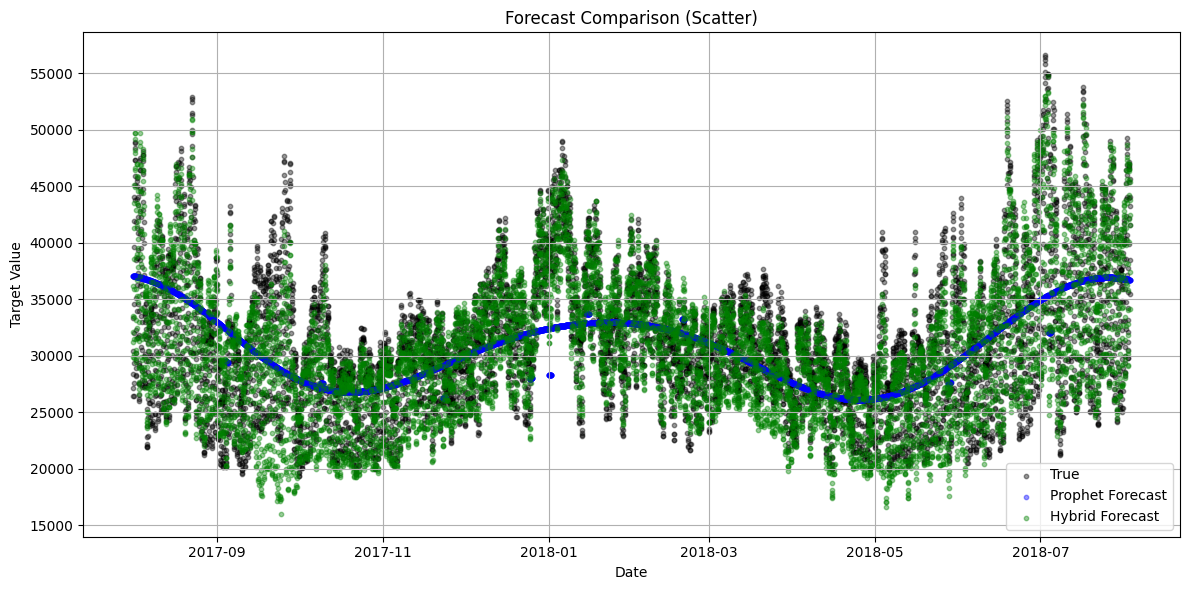

In [94]:
plt.figure(figsize=(12, 6))
plt.scatter(test_set['ds'], test_set['y'], label='True', color='black', s=10, alpha=0.4)
plt.scatter(test_set['ds'], forecast_test['yhat'], label='Prophet Forecast', color='blue', s=10, alpha=0.4)
plt.scatter(test_set['ds'][:len(hybrid_forecast_test)], hybrid_forecast_test, label='Hybrid Forecast', color='green', s=10, alpha=0.4)
plt.legend()
plt.title("Forecast Comparison (Scatter)")
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.grid(True)
plt.tight_layout()
plt.show()

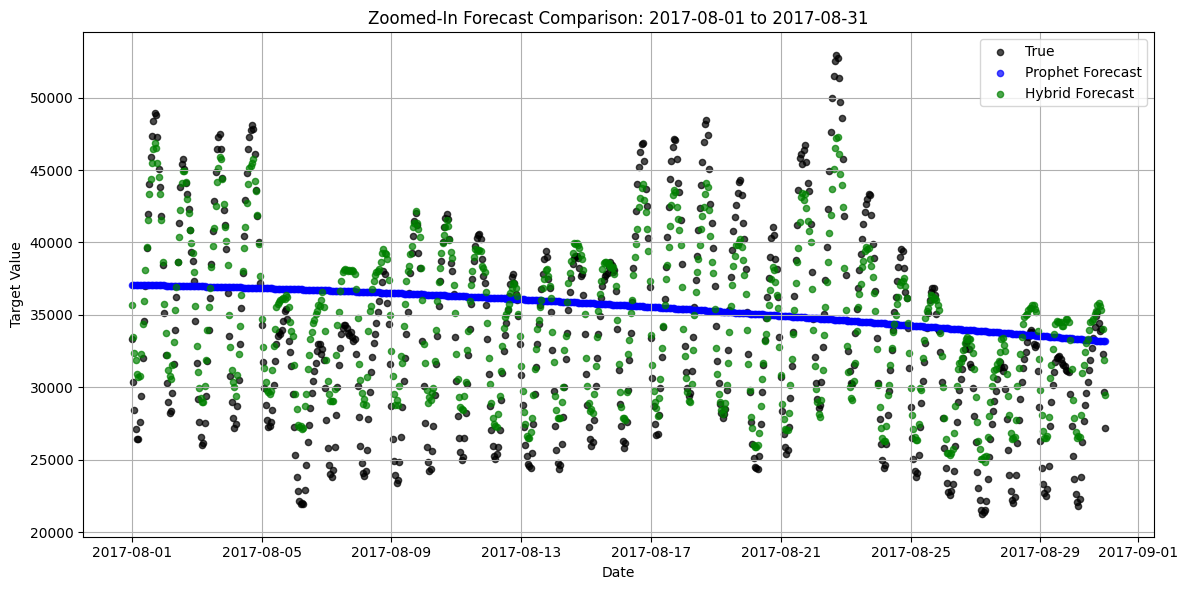

In [74]:
# Create safe copies
test_set_copy = test_set.copy()
forecast_test_copy = forecast_test.copy()

# Reset indices on the copies to ensure alignment
test_set_copy.reset_index(drop=True, inplace=True)
forecast_test_copy.reset_index(drop=True, inplace=True)

# Set zoom-in range
zoom_start = '2017-08-01'
zoom_end = '2017-08-31'

# Create mask based on date range
mask = (test_set_copy['ds'] >= zoom_start) & (test_set_copy['ds'] <= zoom_end)

# Apply mask
ds_zoom = test_set_copy['ds'][mask]
y_true_zoom = test_set_copy['y'][mask]
prophet_zoom = forecast_test_copy['yhat'][mask]

# Create hybrid forecast series aligned with test_set['ds']
hybrid_series = pd.Series(hybrid_forecast_test, index=test_set_copy.index)
hybrid_zoom = hybrid_series[mask]

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(ds_zoom, y_true_zoom, label='True', color='black', s=20, alpha=0.7)
plt.scatter(ds_zoom, prophet_zoom, label='Prophet Forecast', color='blue', s=20, alpha=0.7)
plt.scatter(ds_zoom, hybrid_zoom, label='Hybrid Forecast', color='green', s=20, alpha=0.7)

plt.legend()
plt.title(f"Zoomed-In Forecast Comparison: {zoom_start} to {zoom_end}")
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(test_set['ds'], test_set['y'], label='True', color='black', s=10, alpha=0.4)
plt.scatter(test_set['ds'], forecast_test['yhat'], label='Prophet Forecast', color='blue', s=10, alpha=0.4)
plt.scatter(test_set['ds'][:len(hybrid_forecast_test)], hybrid_forecast_test, label='Hybrid Forecast', color='green', s=10, alpha=0.4)
plt.legend()
plt.title("Forecast Comparison (Scatter)")
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.grid(True)
plt.tight_layout()
plt.show()

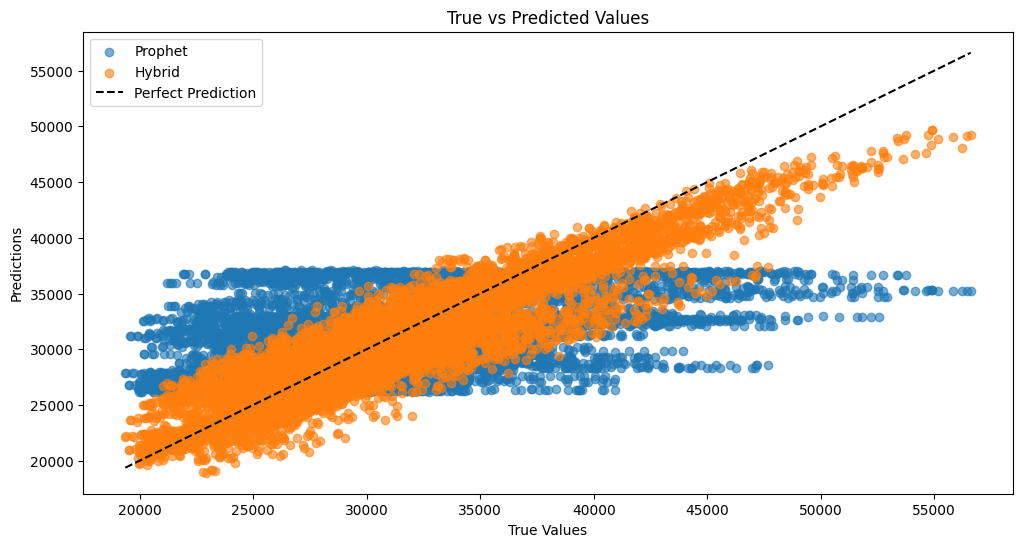

In [57]:
plt.figure(figsize=(12, 6))
plt.scatter(test_set['y'], forecast_test['yhat'], alpha=0.6, label='Prophet')
plt.scatter(test_set['y'][:len(hybrid_forecast_test)], hybrid_forecast_test, alpha=0.6, label='Hybrid')
plt.plot([test_set['y'].min(), test_set['y'].max()],
         [test_set['y'].min(), test_set['y'].max()],
         'k--', label='Perfect Prediction')
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.legend()
plt.show()